# Oregon Kicker Credit Analysis (2024) - TEST Dataset

This notebook analyzes the impact of applying the 2025 Oregon kicker rate to tax year 2024:
- **Baseline**: Current law for 2024 (0% kicker rate)
- **Reform**: 2025 kicker rate (9.86%) applied to 2024

The Oregon kicker is a tax refund provided to taxpayers when state revenues exceed forecasts.

**Note**: Since the kicker is based on prior-year tax liability (`or_tax_before_credits_in_prior_year`), which is an input variable not present in the dataset, we inject current-year tax as a proxy to enable the analysis.

**Dataset:** `hf://policyengine/test/mar/OR.h5`

In [1]:
from policyengine_us import Microsimulation
from policyengine_core.reforms import Reform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Setup Simulations

The baseline is current law for 2024 (0% kicker), while the reform applies the 2025 kicker rate.

In [2]:
DATASET = "hf://policyengine/test/mar/OR.h5"
YEAR = 2024
KICKER_RATE_2025 = 0.09863  # 9.86%

# Step 1: Run initial simulation to get current-year tax before credits
# (used as proxy for prior-year tax)
initial_sim = Microsimulation(dataset=DATASET)
tax_before_credits = initial_sim.calculate("or_income_tax_before_credits", period=YEAR)

print(f"Calculated OR tax before credits for {YEAR}:")
print(f"  Mean: ${tax_before_credits.mean():.2f}")
print(f"  Max: ${tax_before_credits.max():.2f}")

Calculated OR tax before credits for 2024:
  Mean: $6258.89
  Max: $168331344.00


In [3]:
# Step 2: Create simulations with prior-year tax injected
# Reform that applies the 2025 kicker rate to 2024
kicker_reform = Reform.from_dict({
    "gov.states.or.tax.income.credits.kicker.percent": {
        "2024-01-01.2100-12-31": KICKER_RATE_2025
    }
}, country_id="us")

# Baseline: Current law for 2024 (0% kicker)
baseline = Microsimulation(dataset=DATASET)

# Reform: 2025 kicker rate (9.86%) applied to 2024
reformed = Microsimulation(reform=kicker_reform, dataset=DATASET)

# Inject prior-year tax values (using current year as proxy)
baseline.set_input("or_tax_before_credits_in_prior_year", YEAR, tax_before_credits.values)
reformed.set_input("or_tax_before_credits_in_prior_year", YEAR, tax_before_credits.values)

# Check the kicker percent parameters
params_baseline = baseline.tax_benefit_system.parameters
params_reformed = reformed.tax_benefit_system.parameters
kicker_param_baseline = getattr(getattr(getattr(getattr(getattr(getattr(params_baseline.gov.states, "or"), "tax"), "income"), "credits"), "kicker"), "percent")
kicker_param_reformed = getattr(getattr(getattr(getattr(getattr(getattr(params_reformed.gov.states, "or"), "tax"), "income"), "credits"), "kicker"), "percent")
print(f"Baseline kicker percent for {YEAR}: {kicker_param_baseline(f'{YEAR}-01-01') * 100:.2f}%")
print(f"Reform kicker percent for {YEAR}: {kicker_param_reformed(f'{YEAR}-01-01') * 100:.2f}%")

Baseline kicker percent for 2024: 0.00%
Reform kicker percent for 2024: 9.86%


## Household Net Income Impact

In [4]:
baseline_income = baseline.calculate("household_net_income", period=YEAR)
reformed_income = reformed.calculate("household_net_income", period=YEAR)

income_change = reformed_income - baseline_income

# MicroSeries already has weights, so just use .sum() directly
total_income_change = income_change.sum()
print(f"Total change in household net income: ${total_income_change / 1e9:.2f} billion")

Total change in household net income: $1.53 billion


## Budgetary Impact

In [5]:
baseline_state_tax = baseline.calculate("or_income_tax", period=YEAR)
reformed_state_tax = reformed.calculate("or_income_tax", period=YEAR)

# MicroSeries already has weights
baseline_revenue = baseline_state_tax.sum()
reformed_revenue = reformed_state_tax.sum()
revenue_change = reformed_revenue - baseline_revenue

print(f"Baseline state income tax revenue (no kicker): ${baseline_revenue / 1e9:.2f} billion")
print(f"Reformed state income tax revenue (current law): ${reformed_revenue / 1e9:.2f} billion")
print(f"Revenue change (cost of kicker credit): ${revenue_change / 1e9:.2f} billion")

Baseline state income tax revenue (no kicker): $14.50 billion
Reformed state income tax revenue (current law): $12.97 billion
Revenue change (cost of kicker credit): $-1.53 billion


## Kicker Credit Amount

In [6]:
# Calculate the kicker credit directly
kicker_credit = reformed.calculate("or_kicker", period=YEAR)
total_kicker = kicker_credit.sum()

print(f"Total kicker credit claimed: ${total_kicker / 1e9:.2f} billion")

# Handle case where there are no recipients
recipients = kicker_credit > 0
num_recipients = recipients.sum()  # Weighted count

if num_recipients > 0:
    avg_kicker = kicker_credit[recipients].mean()
    print(f"Average kicker credit (among recipients): ${avg_kicker:.2f}")
    print(f"Number of tax units receiving kicker: {num_recipients / 1e6:.2f} million")
else:
    print("No tax units received the kicker credit in this year.")
    print("This is expected if the kicker percent is 0% for the analysis year.")

Total kicker credit claimed: $1.53 billion
Average kicker credit (among recipients): $799.00
Number of tax units receiving kicker: 1.91 million


## Distributional Analysis by Income Decile

In [7]:
# Get household-level data for distributional analysis
income_decile = baseline.calculate("household_income_decile", period=YEAR)

# Calculate change by decile
decile_data = []
for decile in range(1, 11):
    mask = income_decile == decile
    decile_change = income_change[mask].sum()
    decile_hh_count = mask.sum()  # Weighted count
    avg_change = income_change[mask].mean() if mask.any() else 0
    decile_data.append({
        "Decile": decile,
        "Total Change ($B)": decile_change / 1e9,
        "Avg Change per HH ($)": avg_change,
        "Households (M)": decile_hh_count / 1e6
    })

decile_df = pd.DataFrame(decile_data)
decile_df

,Decile,Total Change ($B),Avg Change per HH ($),Households (M)
0,1,0.004514,26.149684,0.172614
1,2,0.017919,83.919678,0.213530
2,3,0.032382,182.121131,0.177803
3,4,0.045437,263.529739,0.172416
4,5,0.061947,389.996697,0.158839
5,6,0.083110,552.904496,0.150315
6,7,0.103007,722.521096,0.142566
7,8,0.139681,1015.777677,0.137511
8,9,0.183602,1448.378142,0.126764
9,10,0.828006,6017.103433,0.137609


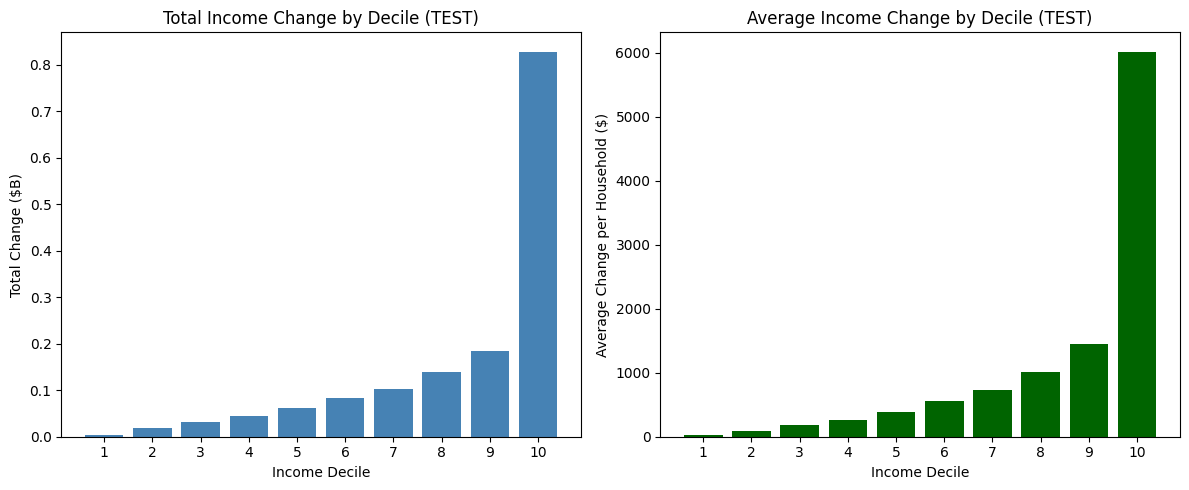

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total change by decile
axes[0].bar(decile_df["Decile"], decile_df["Total Change ($B)"], color="steelblue")
axes[0].set_xlabel("Income Decile")
axes[0].set_ylabel("Total Change ($B)")
axes[0].set_title("Total Income Change by Decile (TEST)")
axes[0].set_xticks(range(1, 11))

# Average change by decile
axes[1].bar(decile_df["Decile"], decile_df["Avg Change per HH ($)"], color="darkgreen")
axes[1].set_xlabel("Income Decile")
axes[1].set_ylabel("Average Change per Household ($)")
axes[1].set_title("Average Income Change by Decile (TEST)")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

## Winners and Losers

In [9]:
winners = income_change > 1  # Gain more than $1
losers = income_change < -1  # Lose more than $1
unchanged = ~winners & ~losers

total_hh = winners.sum() + losers.sum() + unchanged.sum()  # Weighted total

print(f"Households gaining from kicker credit: {winners.sum() / total_hh * 100:.1f}%")
print(f"Households losing from kicker credit: {losers.sum() / total_hh * 100:.1f}%")
print(f"Households unchanged: {unchanged.sum() / total_hh * 100:.1f}%")

if winners.any():
    print(f"\nAverage gain among winners: ${income_change[winners].mean():.2f}")
if losers.any():
    print(f"Average loss among losers: ${income_change[losers].mean():.2f}")

Households gaining from kicker credit: 84.2%
Households losing from kicker credit: 0.0%
Households unchanged: 15.8%

Average gain among winners: $1104.22


## Poverty Impact

In [10]:
baseline_poverty = baseline.calculate("in_poverty", period=YEAR)
reformed_poverty = reformed.calculate("in_poverty", period=YEAR)

# MicroSeries .mean() gives weighted mean
baseline_poverty_rate = baseline_poverty.mean() * 100
reformed_poverty_rate = reformed_poverty.mean() * 100

print(f"Baseline poverty rate (no kicker): {baseline_poverty_rate:.2f}%")
print(f"Reformed poverty rate (with kicker): {reformed_poverty_rate:.2f}%")
print(f"Change in poverty rate: {reformed_poverty_rate - baseline_poverty_rate:.2f} pp")

Baseline poverty rate (no kicker): 25.92%
Reformed poverty rate (with kicker): 25.70%
Change in poverty rate: -0.22 pp


## Summary

In [11]:
print("=" * 50)
print("Oregon Kicker Credit Impact Summary (2024) - TEST")
print("=" * 50)
print(f"\nApplying 2025 kicker rate ({KICKER_RATE_2025*100:.2f}%) to 2024")
print(f"\nFiscal Impact:")
print(f"  Cost to state revenue: ${-revenue_change / 1e9:.2f} billion")
print(f"\nDistributional Impact:")
print(f"  Total benefit to households: ${total_income_change / 1e9:.2f} billion")
print(f"  Share of households benefiting: {winners.sum() / total_hh * 100:.1f}%")
print(f"\nPoverty Impact:")
print(f"  Change in poverty rate: {reformed_poverty_rate - baseline_poverty_rate:.2f} pp")

Oregon Kicker Credit Impact Summary (2024) - TEST

Applying 2025 kicker rate (9.86%) to 2024

Fiscal Impact:
  Cost to state revenue: $1.53 billion

Distributional Impact:
  Total benefit to households: $1.53 billion
  Share of households benefiting: 84.2%

Poverty Impact:
  Change in poverty rate: -0.22 pp
